In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


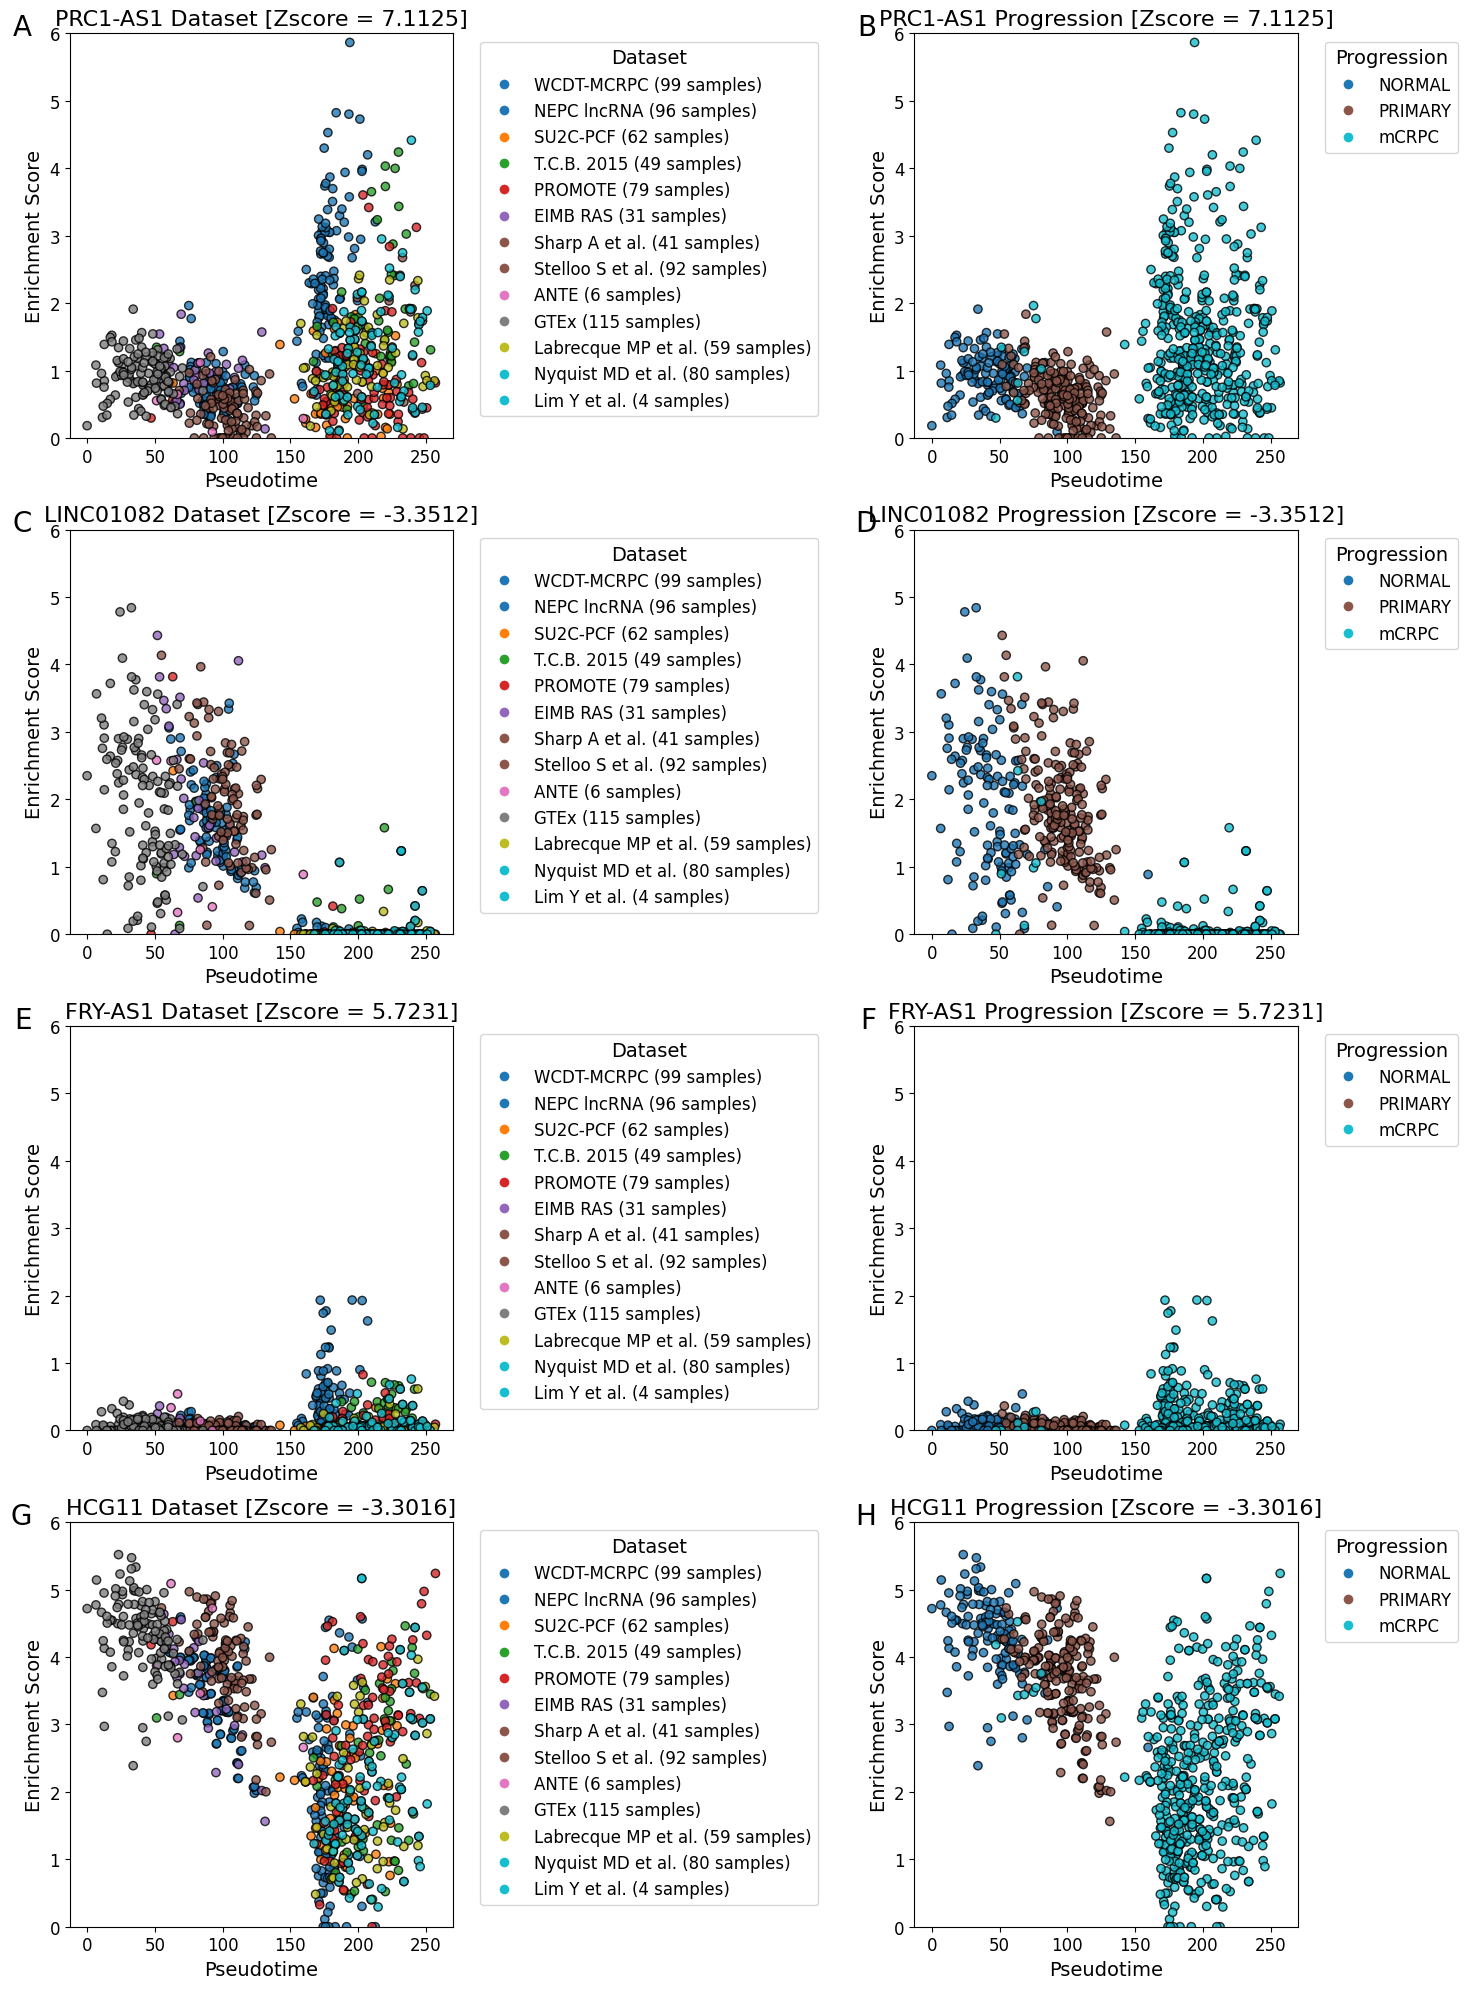

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Define genes, file paths, and Z-scores
genes = ["PRC1-AS1", "LINC01082", "FRY-AS1", "HCG11"]
z_scores = {
    "PRC1-AS1": 7.1125,
    "LINC01082": -3.3512,
    "FRY-AS1": 5.7231,
    "HCG11": -3.3016
}
base_path = "../../../data/Prostate_Atlas/"

# Create figure with 4 rows and 2 columns
fig, axes = plt.subplots(4, 2, figsize=(15, 20))  # 4x2 layout

# Letters for labeling subplots
letters = [chr(i) for i in range(65, 65 + 8)]  # A-H

for i, gene in enumerate(genes):
    # Load bulk dataset
    df_bulk = pd.read_csv(f"{base_path}{gene}_bulk_plot_dataset.csv", sep=",")
    df_bulk.columns = df_bulk.columns.str.strip()
    
    # Bulk scatter plot (left column)
    scatter_bulk = axes[i, 0].scatter(
        x=df_bulk["x"],
        y=df_bulk["y"],
        c=pd.factorize(df_bulk["name"])[0],
        cmap="tab10",
        alpha=0.8,
        edgecolor="k"
    )
    legend_labels_bulk = df_bulk["name"].unique()
    handles_bulk = [
        plt.Line2D([], [], marker="o", color="w", markerfacecolor=scatter_bulk.cmap(scatter_bulk.norm(j)),
                   markersize=8, label=label)
        for j, label in enumerate(legend_labels_bulk)
    ]
    axes[i, 0].legend(handles=handles_bulk, title="Dataset", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12, title_fontsize=14)
    axes[i, 0].set_xlabel("Pseudotime", fontsize=14)
    axes[i, 0].set_ylabel("Enrichment Score", fontsize=14)
    axes[i, 0].set_title(f"{gene} Dataset [Zscore = {z_scores[gene]:.4f}]", fontsize=16)
    axes[i, 0].tick_params(axis='both', which='major', labelsize=12)
    axes[i, 0].set_ylim(0, 6)
    axes[i, 0].text(-0.1, 1.05, letters[i*2], transform=axes[i, 0].transAxes,
                    fontsize=20, va='top', ha='right')

    # Load progression dataset
    df_prog = pd.read_csv(f"{base_path}{gene}_bulk_plot_progression.csv", sep=",")
    df_prog.columns = df_prog.columns.str.strip()
    
    # Progression scatter plot (right column)
    scatter_prog = axes[i, 1].scatter(
        x=df_prog["x"],
        y=df_prog["y"],
        c=pd.factorize(df_prog["name"])[0],
        cmap="tab10",
        alpha=0.8,
        edgecolor="k"
    )
    legend_labels_prog = df_prog["name"].unique()
    handles_prog = [
        plt.Line2D([], [], marker="o", color="w", markerfacecolor=scatter_prog.cmap(scatter_prog.norm(j)),
                   markersize=8, label=label)
        for j, label in enumerate(legend_labels_prog)
    ]
    axes[i, 1].legend(handles=handles_prog, title="Progression", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12, title_fontsize=14)
    axes[i, 1].set_xlabel("Pseudotime", fontsize=14)
    axes[i, 1].set_ylabel("Enrichment Score", fontsize=14)
    axes[i, 1].set_title(f"{gene} Progression [Zscore = {z_scores[gene]:.4f}]", fontsize=16)
    axes[i, 1].tick_params(axis='both', which='major', labelsize=12)
    axes[i, 1].set_ylim(0, 6)
    axes[i, 1].text(-0.1, 1.05, letters[i*2 + 1], transform=axes[i, 1].transAxes,
                    fontsize=20, va='top', ha='right')

plt.tight_layout()
fig.savefig("../../figures/Prostate_Atlas.png", dpi=300, bbox_inches='tight')
plt.show()


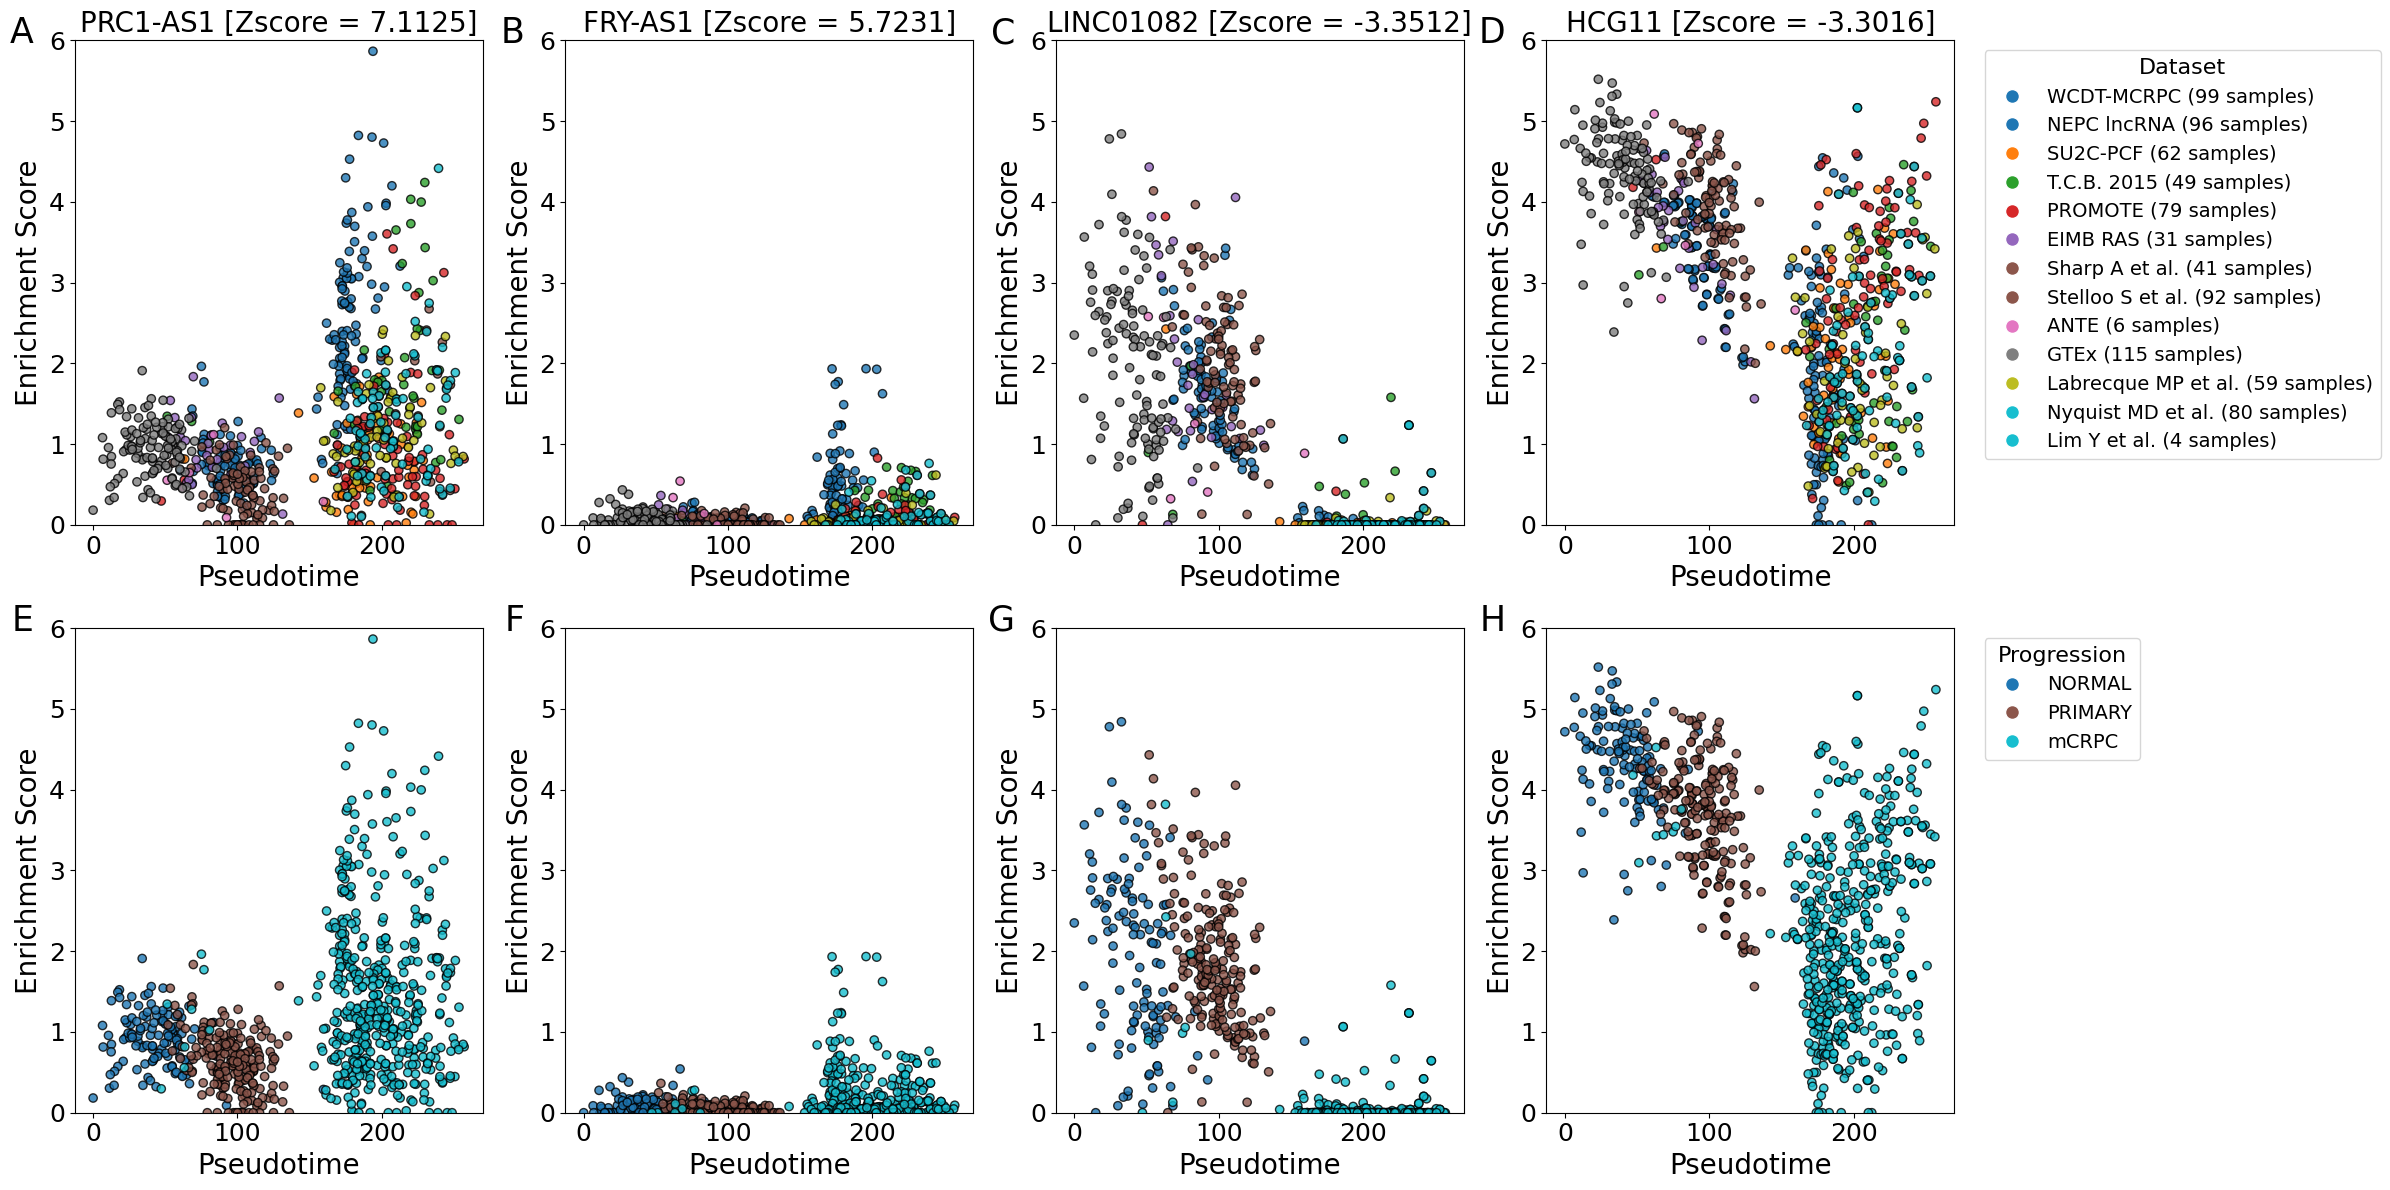

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Define genes, file paths, and Z-scores
genes = ["PRC1-AS1", "FRY-AS1", "LINC01082", "HCG11"]
z_scores = {
    "PRC1-AS1": 7.1125,
    "LINC01082": -3.3512,
    "FRY-AS1": 5.7231,
    "HCG11": -3.3016
}
base_path = "../../../data/Prostate_Atlas/"

# Create figure with 2 rows and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(24, 12))  # slightly taller for larger fonts
axes = axes.flatten()  # Flatten for easy indexing

# Letters for labeling subplots
letters = [chr(i) for i in range(65, 73)]  # A-H

# Colors for consistency
colors = plt.cm.tab10(range(len(genes)))

# Font sizes
title_fs = 20
axis_fs = 20
letter_fs = 25

for i, gene in enumerate(genes):
    # Load datasets
    df_bulk = pd.read_csv(f"{base_path}{gene}_bulk_plot_dataset.csv", sep=",")
    df_bulk.columns = df_bulk.columns.str.strip()
    df_prog = pd.read_csv(f"{base_path}{gene}_bulk_plot_progression.csv", sep=",")
    df_prog.columns = df_prog.columns.str.strip()
    
    # Dataset plot (top row)
    scatter_bulk = axes[i].scatter(
        df_bulk["x"], df_bulk["y"],
        c=pd.factorize(df_bulk["name"])[0],
        cmap="tab10",
        alpha=0.8,
        edgecolor="k"
    )
    axes[i].set_xlabel("Pseudotime", fontsize=axis_fs)
    axes[i].set_ylabel("Enrichment Score", fontsize=axis_fs)
    axes[i].set_title(f"{gene} [Zscore = {z_scores[gene]:.4f}]", fontsize=title_fs)
    axes[i].set_ylim(0, 6)
    axes[i].tick_params(axis='both', which='major', labelsize=axis_fs-2)
    axes[i].text(-0.1, 1.05, letters[i], transform=axes[i].transAxes,
                 fontsize=letter_fs, va='top', ha='right')
    
    # Add legend only to the 4th subplot (Dataset)
    if i == 3:
        handles = [
            plt.Line2D([], [], marker='o', color='w', markerfacecolor=scatter_bulk.cmap(scatter_bulk.norm(j)),
                       markersize=10, label=label)
            for j, label in enumerate(df_bulk["name"].unique())
        ]
        axes[i].legend(handles=handles, title="Dataset", fontsize=14, title_fontsize=16,
                       loc='upper left', bbox_to_anchor=(1.05, 1))
    
    # Progression plot (bottom row)
    scatter_prog = axes[i + 4].scatter(
        df_prog["x"], df_prog["y"],
        c=pd.factorize(df_prog["name"])[0],
        cmap="tab10",
        alpha=0.8,
        edgecolor="k"
    )
    axes[i + 4].set_xlabel("Pseudotime", fontsize=axis_fs)
    axes[i + 4].set_ylabel("Enrichment Score", fontsize=axis_fs)
    # No title for E-H
    axes[i + 4].set_ylim(0, 6)
    axes[i + 4].tick_params(axis='both', which='major', labelsize=axis_fs-2)
    axes[i + 4].text(-0.1, 1.05, letters[i + 4], transform=axes[i + 4].transAxes,
                     fontsize=letter_fs, va='top', ha='right')
    
    # Add legend only to the 8th subplot (Progression)
    if i == 3:
        handles_prog = [
            plt.Line2D([], [], marker='o', color='w', markerfacecolor=scatter_prog.cmap(scatter_prog.norm(j)),
                       markersize=10, label=label)
            for j, label in enumerate(df_prog["name"].unique())
        ]
        axes[i + 4].legend(handles=handles_prog, title="Progression", fontsize=14, title_fontsize=16,
                            loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
fig.savefig("../../figures/Prostate_Atlas_2x4.png", dpi=300, bbox_inches='tight')
plt.show()
